In [1]:
%pip install nltk
%pip install tensorflow
%pip install keras


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:

import json

with open('intents.json') as f:
    intents=json.load(f)
print("Number of intents: ",len(intents['intents']))
print("Tags: ",[i['tag'] for i in intents['intents']])

Number of intents:  8
Tags:  ['greeting', 'dad_jokes', 'programming_jokes', 'knock_knock', 'animal_jokes', 'puns', 'one_liners', 'goodbye']


In [18]:
sample=intents['intents'][0]
print('Tag: ',sample['tag'])#tags pattersn responses are keys
print('Patterns: ',sample['patterns'])
print('Responses: ',sample['responses'])

Tag:  greeting
Patterns:  ['Hi', 'Hello', 'Hey', 'Is anyone there?', 'Tell me a joke']
Responses:  ['Hello! Ready for some laughs? Ask me for a joke!', 'Hey there! Need a laugh? Just ask!', "Hi! I'm your resident joke bot. What kind of joke are you in the mood for?"]


In [20]:
total_patterns=sum(len(i['patterns']) for i in intents['intents'])
print("Total num. of sentences: ",total_patterns)

Total num. of sentences:  36


In [22]:
import nltk 
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LORDS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LORDS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LORDS\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LORDS\AppData\Roaming\nltk_data...


True

In [24]:
lemmatizer=WordNetLemmatizer()
#demo sentence for tokenization and lemmatizied 
demo_sentence="what is the name of the developers"
tokens=nltk.word_tokenize(demo_sentence)
lemmatized=[lemmatizer.lemmatize(t.lower()) for t in tokens]

print("Original sentence : ",demo_sentence)
print(" tokens: ",tokens)
print(" lemmatized: ",lemmatized)

Original sentence :  what is the name of the developers
 tokens:  ['what', 'is', 'the', 'name', 'of', 'the', 'developers']
 lemmatized:  ['what', 'is', 'the', 'name', 'of', 'the', 'developer']


In [26]:
words=[]
classes =[]
documents=[]
ignore=['?',',','.','!']

In [28]:
for intent in intents['intents']:
    for pattern in intent['patterns']:
        tokens=nltk.word_tokenize(pattern)
        words.extend(tokens)
        documents.append((tokens,intent['tag']))
    if intent['tag'] not in classes:
        classes.append(intent['tag'])

In [30]:
words=[lemmatizer.lemmatize(w.lower()) for w in words if w not in ignore]
words=sorted(set(words))
classes=sorted(set(classes))

print(len(documents),"training completed")
print(len(classes),"intents",classes)
print(len(words),"unique words in vocabulary")

36 training completed
8 intents ['animal_jokes', 'dad_jokes', 'goodbye', 'greeting', 'knock_knock', 'one_liners', 'programming_jokes', 'puns']
52 unique words in vocabulary


In [32]:
import random 
import numpy as np
training=[]
output_empty=[0]*len(classes)
for tokens,tag in documents:
    lemmatized_tokens=[lemmatizer.lemmatize(t.lower()) for t in tokens]
    bag=[1 if w in lemmatized_tokens else 0 for w in words]

    output_row=list(output_empty)

    output_row[classes.index(tag)]=1
    training.append([bag,output_row])
random.shuffle(training)

In [34]:
train_x=np.array([row[0] for row in training],dtype=np.float32)
train_y=np.array([row[1] for row in training],dtype=np.float32)

print("Train X shape: ",train_x.shape)
print("Train Y shape: ",train_y.shape)

Train X shape:  (36, 52)
Train Y shape:  (36, 8)


In [36]:
#model evaluation --> neural networks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Input
from tensorflow.keras.optimizers import SGD

In [38]:
model=Sequential([
    Input(shape=(len(train_x[0]),)),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(32,activation="relu"),
    Dropout(0.5),
    Dense(len(train_y[0]),activation='softmax'),
])
sgd=SGD(learning_rate=0.01,momentum=0.9,nesterov=True)
model.compile(loss='categorical_crossentropy',optimizer=sgd,
             metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           3,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,736 (22.41 KB)

 Trainable params: 5,736 (22.41 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history=model.fit(train_x,train_y,epochs=200,batch_size=8)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1667 - loss: 2.1809  
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1667 - loss: 2.1475      
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1111 - loss: 2.0616     
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2778 - loss: 2.0402 
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2778 - loss: 2.0752 
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1389 - loss: 2.0227     
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1667 - loss: 1.9962 
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2500 - loss: 1.9761 
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1944 - loss: 1.9705 
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2222 - loss: 2.0046 
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2778 - loss: 1.9317     
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accu

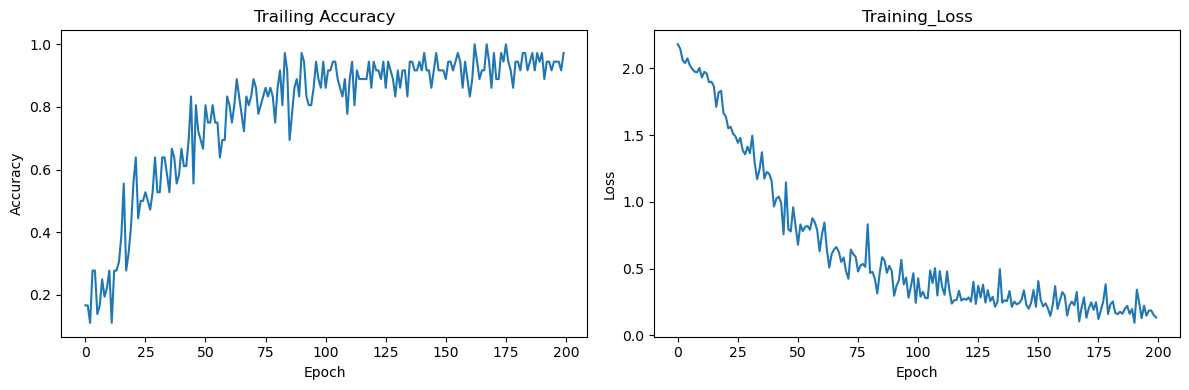

In [42]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history['accuracy'])
axes[0].set_title("Trailing Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

axes[1].plot(history.history['loss'])
axes[1].set_title("Training_Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [44]:
#save 
import pickle
model.save('chatbot_model.keras') 
with open('words.pkl','wb') as f:
    pickle.dump(words,f)
with open('classes.pkl','wb') as f:
    pickle.dump(classes,f)

print("Saved : chatbot_model.keras,words.pkl,classes.pkl")

Saved : chatbot_model.keras,words.pkl,classes.pkl
